In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("final_dataset.csv")


df

,year,country,christianity,judaism,islam,buddhism,hindu,shinto,confus_tao,code,gdp,un_region,conflict_present,hdi,population
0,1990,United States,214425162,5508504,2294757,1575481,323352,59724,106818,USA,5.963144e+12,Northern America,0.0,0.88,249623000.0
1,1995,United States,215593975,5259463,2425377,1608346,574269,57972,62455,USA,7.639749e+12,Northern America,0.0,0.89,266278000.0
2,2000,United States,219818305,5010424,2555997,2449569,825186,56220,18093,USA,1.025095e+13,Northern America,0.0,0.89,282162411.0
3,2005,United States,226464805,5536622,2685374,3682694,1311442,60560,90593,USA,1.303920e+13,Northern America,0.0,0.91,295516599.0
4,2010,United States,233111307,5942248,2814750,3410236,1797698,156375,95752,USA,1.504896e+13,Northern America,0.0,0.92,309378227.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
774,1990,Samoa,159500,0,37,15,0,0,0,WSM,1.257663e+08,Oceania,0.0,0.66,169042.0
775,1995,Samoa,161677,0,43,16,0,0,0,WSM,2.248657e+08,Oceania,0.0,0.66,174571.0
776,2000,Samoa,174600,0,50,18,0,0,0,WSM,2.588561e+08,Oceania,0.0,0.67,181685.0
777,2005,Samoa,177510,0,58,18,0,0,0,WSM,4.768018e+08,Oceania,0.0,0.69,186978.0


## CONTROLLING FOR POPULATION

We are trying to understand whether countries experiencing conflict tend to be more religious.

To do this, we compare two groups of countries:

Countries with conflict

Countries without conflict

For each group, we calculate the average level of religious affiliation over time.

But we look at it in two different ways - we cannot only look at the number of religious population if we did then large countries will automatically appear more religious due to their population size. Thus we need a measure that removes population size effects

1. religious_population = number of religious people (only for christianity, judaism, hindu, buddhism, islam, shinto, confus tao)
2. religious_share = the percentage of the population that is religious 

In [7]:
religion_cols = [
"christianity","judaism","islam",
"buddhism","hindu","shinto","confus_tao"]

df["religious_population"] = df[religion_cols].sum(axis=1)

# ensure religious population cannot exceed population
df["religious_population"] = df[["religious_population","population"]].min(axis=1)
df["religious_share"] = df["religious_population"] / df["population"]



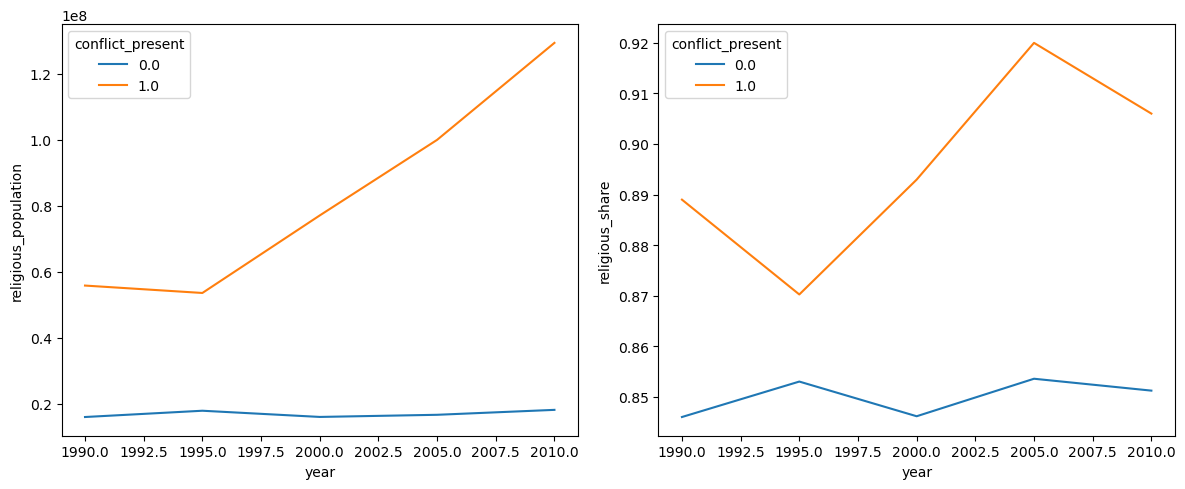

In [14]:
#Now we plot our variables

relig_avg = df.groupby(["year","conflict_present"])["religious_population"].mean().reset_index() 
share_avg = df.groupby(["year","conflict_present"])["religious_share"].mean().reset_index()

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.lineplot(
    data=relig_avg,
    x="year",
    y="religious_population",
    hue="conflict_present",
    errorbar=None,
    ax=axes[0]
)

sns.lineplot(
    data=share_avg,
    x="year",
    y="religious_share",
    hue="conflict_present",
    errorbar=None,
    ax=axes[1]
)
plt.xticks(sorted(df["year"].unique()))

plt.tight_layout()

## Results 

The left graph gives us the average religious population and shows how countries with conflict have a larger religious population - but as we mentioned before this could be due to population size so we need to look at average religious share

- We can see that from 1995 the average religious population for countries in conflict rose significantly
- Average religious population for non-conflict countries remain relatively stable through the years 

The right graph then shows the share of people who are religious removing the effect of population size

- We can observe that from 1990 until 1995 conflict countries experienced a drop in religious population
- From 1995 however conflict countries experienced an increase in religious population until 2000, where after it began declining afain until 2010
- For non-conflict countries from 1990 they experienced a decline in religious population with the biggest drop being from 2000 to 2005.

However, in order to fully understand why these drops happened it is necessary to look at religious_share and religious_population by region to see if these effects came from a primary region 



### FILTERING BY REGION 

In [9]:
relig_avg = df.groupby(["un_region","year","conflict_present"])["religious_population"].mean().reset_index()
share_avg = df.groupby(["un_region","year","conflict_present"])["religious_share"].mean().reset_index()

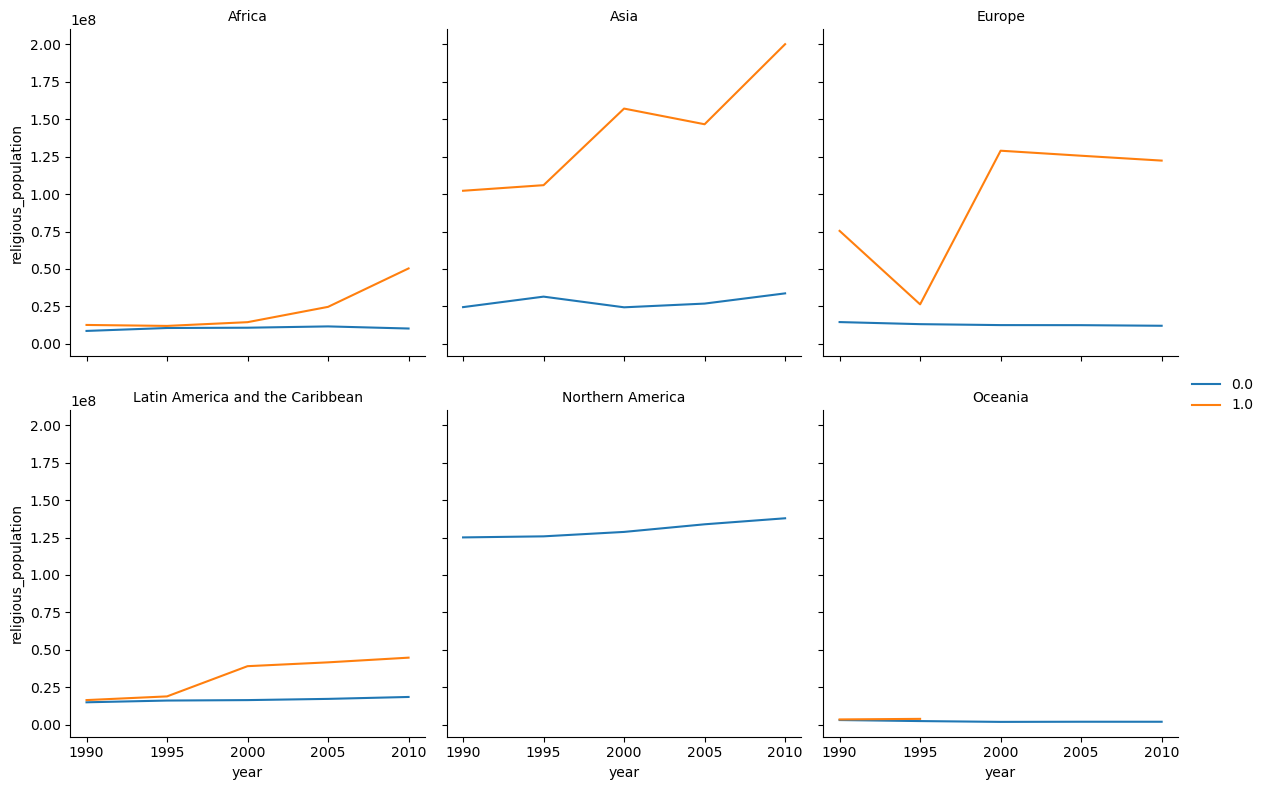

In [10]:
#Looking at the religious population by region 


g = sns.FacetGrid(relig_avg, col="un_region", col_wrap=3, height=4)

g.map_dataframe(sns.lineplot,x="year",y="religious_population",hue="conflict_present")
g.add_legend()
g.set_titles("{col_name}")

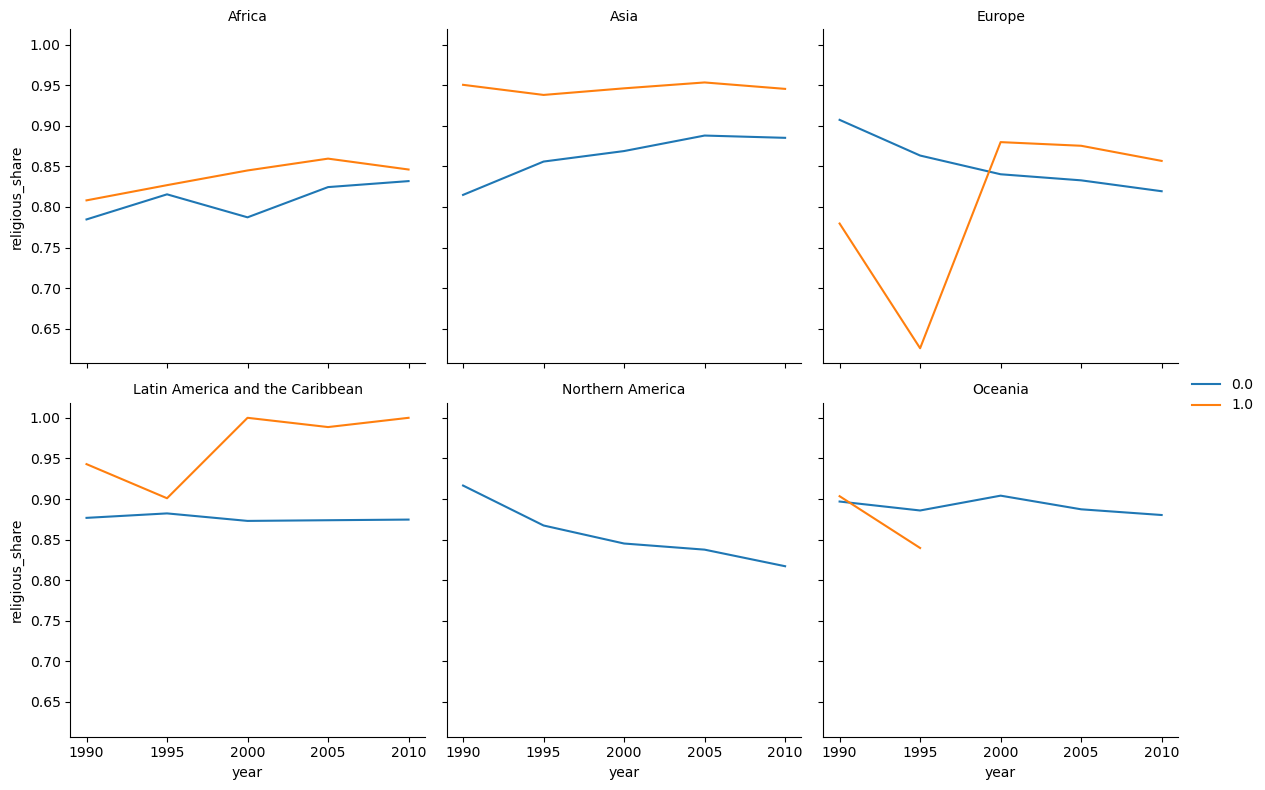

In [11]:
#Looking at the religious share by region 

g = sns.FacetGrid(share_avg, col="un_region", col_wrap=3, height=4)

g.map_dataframe(
    sns.lineplot,
    x="year",
    y="religious_share",
    hue="conflict_present")

g.add_legend()
g.set_titles("{col_name}")

### Results

From the religious population by region graphs we can see: 

1. *Africa*: Both conflict and non-conflict countries in Africa experienced steady growth in religious population
2. *Asia*: Conflict countries in Asia experienced a big increase in religious population between 1995 and 2000, after 2000 it dropped slightly but began rising again in 2005. Non-conflict countries experienced a stable rate of religious population from 1990 to 2010
3. *Europe*: In Europe, non-conflict countries remained stable in their religious population rates. For conflict countries between 1990 and 1995 there was a steep decline but was then followed by a big increase until 2000, after 2000 it remained stable
4. *Latin America and the Caribbean*: Countries experienced a steady increase in religious population
5. *Northern America*: There were no conflict countries in Northern America so we can only see a stead increase in religious population in non-conflict countries. religious population was already high in non-conflict countries in Northern America.
6. *Oceania*: In Oceania religious population remained the same, conflicts stopped in the region after 1995 from there we can only observer the religious population of non-conflict countries which remained pretty stable



From the relgious share by region graphs we can see: 


1. *Africa*: Both conflict and non-conflict countries show relatively high levels of religious share. Non-conflict countries experienced a small dip around 2000 but then increased again, while conflict countries peaked around 1995–2000 before gradually declining slightly toward 2010.
2. *Asia*: Religious share remained very high across the entire period for both groups. Non-conflict countries saw a peak around 2000 followed by a decline after 2000. Conflict countries experienced a slight drop from 1990 to 1995 and then remained relatively stable from 1995 to 2010.
3. *Europe*: Non-conflict countries show a steady decline in religious share from 1990 to 2010. Conflict countries experienced a sharp drop between 1990 and 1995, followed by a strong increase by 2000, after which religious share gradually declined again toward 2010.
4. *Latin America and the Caribbean*: Religious share remained consistently high throughout the period. Conflict countries show some fluctuations, with a noticeable increase around 2000 followed by a slight decline. Non-conflict countries remained very stable across the years.
5. *Northern America*: There were no conflict countries observed in the region. Non-conflict countries show a gradual decline in religious share from 1990 to 2010, suggesting a steady secularization trend.
6. *Oceania*: Religious share in non-conflict countries increased slightly between 1995 and 2000 before gradually declining toward 2010. Conflict countries appear only in the early years (1990–1995), after which only non-conflict countries remain in the data.


#### Conclusion: 

The regional graphs help explain the patterns observed in the overall average religious share graph. The temporary peak in the global average around 2000 appears to be largely influenced by regional changes, particularly in Europe and Latin America and the Caribbean, where conflict countries experienced sharp increases in religious share during this period. At the same time, regions such as Asia and Africa maintained consistently high levels of religiosity, which helped keep the overall global average relatively stable.

Meanwhile, the gradual decline in the global religious share for non-conflict countries can be explained by trends in Europe and Northern America, where religious share steadily decreases over time. Together, these regional patterns show that the global averages are driven by a combination of regional secularization in developed regions and consistently high religiosity in other parts of the world. This suggests that regional and demographic factors play a larger role, while conflict may reinforce religiosity slightly rather than dramatically increasing it.

### Statistical test:

In [12]:
import pandas as pd
import statsmodels.api as sm

X = df["conflict_present"]     
y = df["religious_share"]


X = sm.add_constant(X)
model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:        religious_share   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     8.469
Date:                Thu, 12 Mar 2026   Prob (F-statistic):            0.00372
Time:                        17:09:34   Log-Likelihood:                 379.34
No. Observations:                 779   AIC:                            -754.7
Df Residuals:                     777   BIC:                            -745.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.8502      0.006  

The regression results indicate a positive and statistically significant relationship between conflict and religious affiliation share. Countries experiencing conflict have, on average, a 4.3 percentage point higher level of religious affiliation compared to countries without conflict (β = 0.0433, p = 0.004). The 95% confidence interval (0.014–0.073) suggests that the true effect is likely between 1.4 and 7.3 percentage points, providing further evidence that conflict is associated with higher levels of religious affiliation.

In [13]:
df.describe()

,year,christianity,judaism,islam,buddhism,hindu,shinto,confus_tao,gdp,conflict_present,hdi,population,religious_population,religious_share
count,779.000000,7.790000e+02,7.790000e+02,7.790000e+02,7.790000e+02,7.790000e+02,7.790000e+02,7.790000e+02,7.790000e+02,779.000000,743.000000,7.790000e+02,7.790000e+02,779.000000
mean,2000.378691,1.118533e+07,9.020469e+04,6.718515e+06,2.607970e+06,5.414260e+06,6.461668e+05,5.736894e+04,2.446232e+11,0.151476,0.648331,3.596410e+07,2.620366e+07,0.856782
std,6.966988,2.641862e+07,5.935764e+05,2.352130e+07,1.500164e+07,6.451393e+07,8.045249e+06,4.833379e+05,1.037712e+12,0.358743,0.173343,1.348120e+08,8.710346e+07,0.149593
min,1990.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.210000,9.544000e+03,9.544000e+03,0.157589
25%,1995.000000,2.761590e+05,0.000000e+00,5.925000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.078968e+09,0.000000,0.510000,1.960646e+06,1.519310e+06,0.804224
50%,2000.000000,2.274495e+06,1.940000e+02,2.546000e+05,3.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.271074e+10,0.000000,0.670000,7.437115e+06,6.112145e+06,0.903446
75%,2005.000000,8.059301e+06,4.200000e+03,2.464248e+06,1.010000e+04,1.377000e+04,0.000000e+00,0.000000e+00,9.581173e+10,0.000000,0.780000,2.031758e+07,1.715053e+07,0.959472
max,2010.000000,2.331113e+08,5.942248e+06,2.015500e+08,1.694920e+08,9.614011e+08,1.080000e+08,5.200000e+06,1.504896e+13,1.000000,0.940000,1.337705e+09,1.163660e+09,1.000000


### Descriptive Statistics: Main Characteristics of our dataset 

- The dataset contains 779 country–year observations covering the years 1990–2010, with slightly fewer observations for HDI (743) due to missing data.

- On average, about 86% of a country’s population is religious, indicating that religious affiliation is generally high across the dataset.

- The median religious share (0.90) is slightly higher than the mean, suggesting most countries are highly religious while a smaller number of more secular countries lower the average.

- The standard deviation of religious share (0.15) indicates moderate variation in religiosity between countries.

- Population varies greatly across countries (from about 9,500 to over 1.3 billion), meaning the dataset includes both very small and very large countries.

- As a result, religious population also varies widely, largely reflecting differences in total population size.

- Christianity and Islam have the largest average populations across countries, while religions such as Judaism, Shinto, and Confucian/Tao traditions tend to have smaller and more geographically concentrated populations.

- GDP varies significantly across countries, indicating large differences in economic development.

- HDI also shows noticeable variation, with values ranging from 0.21 to 0.94, reflecting different levels of human development.

- Approximately 15% of country–year observations involve conflict, meaning most observations represent non-conflict countries but there are enough conflict cases to analyze their potential relationship with religiosity.

